### 1. Import libraries and define constants

In [1]:
from pathlib import Path
import json
import re

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler

try:
    from IPython.display import display
except Exception:
    def display(obj):
        print(obj)

RANDOM_STATE = 42
IQR_MULTIPLIER = 1.5
CORRELATION_THRESHOLD = 0.80
DATASET_PATH = Path("pakwheels_pakistan_automobile_dataset.csv")
ARTIFACTS_DIR = Path("artifacts")

BASE_NUMERIC_FEATURES = ["mileage", "engine_capacity", "vehicle_age"]
BASE_CATEGORICAL_FEATURES = ["fuel_type", "transmission", "assembly", "brand", "model_name"]
TARGET = "price"
MIN_CATEGORY_COUNT = 20


### 2. Feature engineering: extract brand and model from title

In [2]:
def extract_brand_and_model(title: str) -> tuple[str, str]:
    if pd.isna(title):
        return "unknown", "unknown"

    clean_title = re.sub(r"\s+", " ", str(title)).strip().lower()
    if not clean_title:
        return "unknown", "unknown"

    tokens = clean_title.split(" ")
    brand = tokens[0]
    model_name = " ".join(tokens[1:3]) if len(tokens) > 1 else "unknown"

    return brand, model_name


### 3. Load, clean, and filter outliers using IQR

In [3]:
def iqr_filter(data: pd.DataFrame, column: str, multiplier: float = IQR_MULTIPLIER) -> pd.DataFrame:
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - multiplier * iqr
    upper = q3 + multiplier * iqr

    return data[(data[column] >= lower) & (data[column] <= upper)]


def load_and_clean_data(csv_path: Path) -> pd.DataFrame:
    required_columns = ["title", "mileage", "engine_capacity", "vehicle_age", "fuel_type", "transmission", "assembly", TARGET]
    df = pd.read_csv(str(csv_path))

    missing_columns = [col for col in required_columns if col not in df.columns]
    if missing_columns:
        raise ValueError(f"Missing required columns: {missing_columns}")

    data = df[required_columns].copy().drop_duplicates()

    # Base sanity filters.
    data = data[
        (data[TARGET] > 0)
        & (data["engine_capacity"] > 0)
        & (data["mileage"] >= 0)
        & (data["vehicle_age"] >= 0)
    ]

    # Feature engineering from title.
    parsed = data["title"].apply(extract_brand_and_model)
    data["brand"] = parsed.str[0]
    data["model_name"] = parsed.str[1]

    # IQR-based outlier removal on the most sensitive variables.
    for col in [TARGET, "mileage", "engine_capacity"]:
        data = iqr_filter(data, col)

    # Reduce rare values to keep one-hot space stable and reduce unseen-category warnings.
    top_models = data["model_name"].value_counts().nlargest(80).index
    data.loc[~data["model_name"].isin(top_models), "model_name"] = "other"

    for col in BASE_CATEGORICAL_FEATURES:
        counts = data[col].value_counts()
        rare_values = counts[counts < MIN_CATEGORY_COUNT].index
        data.loc[data[col].isin(rare_values), col] = "other"

    return data.dropna()


car = load_and_clean_data(DATASET_PATH)
print(f"Rows after cleaning and IQR filtering: {len(car):,}")
car[["title", "brand", "model_name", "mileage", "engine_capacity", "vehicle_age", "price"]].head()


Rows after cleaning and IQR filtering: 41,080


,title,brand,model_name,mileage,engine_capacity,vehicle_age,price
0,Honda N One Premium 2014,honda,other,82000,660,10,2650000
1,Nissan Note 2020,nissan,other,59000,1200,4,5400000
3,Toyota Yaris Cross 2021,toyota,other,41000,1500,3,7850000
5,Honda City Aspire Prosmatec 1.5 i-VTEC 2016,honda,city aspire,45000,1500,8,3600000
6,Toyota Corolla Altis Grande X CVT-i 1.8 Beige ...,toyota,corolla altis,59500,1800,2,6475000


### 4. Multicollinearity check and feature policy

In [4]:
def apply_multicollinearity_policy(train_df: pd.DataFrame, test_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, list[str], float, str]:
    corr = float(train_df["mileage"].corr(train_df["vehicle_age"]))

    numeric_features = BASE_NUMERIC_FEATURES.copy()
    decision = "keep_all_numeric_features"

    if abs(corr) >= CORRELATION_THRESHOLD:
        # If strongly correlated, combine signals and drop raw mileage.
        train_df = train_df.copy()
        test_df = test_df.copy()

        train_df["mileage_per_year"] = train_df["mileage"] / (train_df["vehicle_age"] + 1)
        test_df["mileage_per_year"] = test_df["mileage"] / (test_df["vehicle_age"] + 1)

        numeric_features = ["engine_capacity", "vehicle_age", "mileage_per_year"]
        train_df = train_df.drop(columns=["mileage"])
        test_df = test_df.drop(columns=["mileage"])
        decision = "high_corr_detected_dropped_mileage_added_mileage_per_year"

    return train_df, test_df, numeric_features, corr, decision


### 5. Build robust preprocessing and candidate models

In [5]:
def build_preprocessor(numeric_features: list[str], categorical_features: list[str]) -> ColumnTransformer:
    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", RobustScaler()),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="infrequent_if_exist",
                    min_frequency=MIN_CATEGORY_COUNT,
                ),
            ),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_features),
            ("cat", categorical_pipeline, categorical_features),
        ]
    )


def build_candidate_models(numeric_features: list[str], categorical_features: list[str]) -> dict[str, Pipeline]:
    preprocessor = build_preprocessor(numeric_features, categorical_features)

    linear_model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "regressor",
                TransformedTargetRegressor(
                    regressor=LinearRegression(),
                    func=np.log1p,
                    inverse_func=np.expm1,
                ),
            ),
        ]
    )

    ridge_model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "regressor",
                TransformedTargetRegressor(
                    regressor=Ridge(alpha=10.0, random_state=RANDOM_STATE),
                    func=np.log1p,
                    inverse_func=np.expm1,
                ),
            ),
        ]
    )

    lasso_model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "regressor",
                TransformedTargetRegressor(
                    regressor=Lasso(alpha=0.0008, max_iter=20000, random_state=RANDOM_STATE),
                    func=np.log1p,
                    inverse_func=np.expm1,
                ),
            ),
        ]
    )

    return {
        "linear_log_target": linear_model,
        "ridge_log_target": ridge_model,
        "lasso_log_target": lasso_model,
    }


### 6. Train/test split and cross-validation model selection

In [6]:
def evaluate_by_cv(X: pd.DataFrame, y: pd.Series, model: Pipeline) -> dict[str, float]:
    cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring={
            "mae": "neg_mean_absolute_error",
            "rmse": "neg_root_mean_squared_error",
            "r2": "r2",
        },
        n_jobs=-1,
        error_score="raise",
    )

    return {
        "cv_mae": float(-scores["test_mae"].mean()),
        "cv_rmse": float(-scores["test_rmse"].mean()),
        "cv_r2": float(scores["test_r2"].mean()),
    }


all_features = BASE_NUMERIC_FEATURES + BASE_CATEGORICAL_FEATURES
X = car[all_features]
y = car[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

X_train_adj, X_test_adj, numeric_features, age_mileage_corr, multicollinearity_decision = apply_multicollinearity_policy(X_train, X_test)
categorical_features = BASE_CATEGORICAL_FEATURES.copy()

print(f"Mileage vs vehicle_age correlation (train): {age_mileage_corr:.4f}")
print(f"Multicollinearity decision: {multicollinearity_decision}")
print(f"Numeric features used: {numeric_features}")

candidates = build_candidate_models(numeric_features, categorical_features)
all_scores: dict[str, dict[str, float]] = {}

for name, model in candidates.items():
    all_scores[name] = evaluate_by_cv(X_train_adj, y_train, model)

scores_df = pd.DataFrame(all_scores).T.sort_values("cv_rmse")
selected_model_name = scores_df.index[0]
selected_model = candidates[selected_model_name]
selected_model.fit(X_train_adj, y_train)

print("Model comparison (lower RMSE is better):")
display(scores_df)
print(f"Selected model: {selected_model_name}")


Mileage vs vehicle_age correlation (train): 0.4649
Multicollinearity decision: keep_all_numeric_features
Numeric features used: ['mileage', 'engine_capacity', 'vehicle_age']
Model comparison (lower RMSE is better):


,cv_mae,cv_rmse,cv_r2
linear_log_target,397677.335838,639134.561883,0.893922
ridge_log_target,403223.449564,645097.859408,0.891924
lasso_log_target,472424.289287,732720.358948,0.860569


Selected model: linear_log_target


### 7. Evaluate on test set and run diagnostics

------------------------------------------------------------
CAR PRICE REGRESSION REPORT
------------------------------------------------------------
Rows used for training after cleaning: 41,080
Selected model variant: linear_log_target

Cross-validation (5-fold):
  MAE : Rs. 397,677.34
  RMSE: Rs. 639,134.56
  R2  : 0.8939

Holdout test set:
  MAE : Rs. 390,693.65
  RMSE: Rs. 630,396.55
  R2  : 0.8954


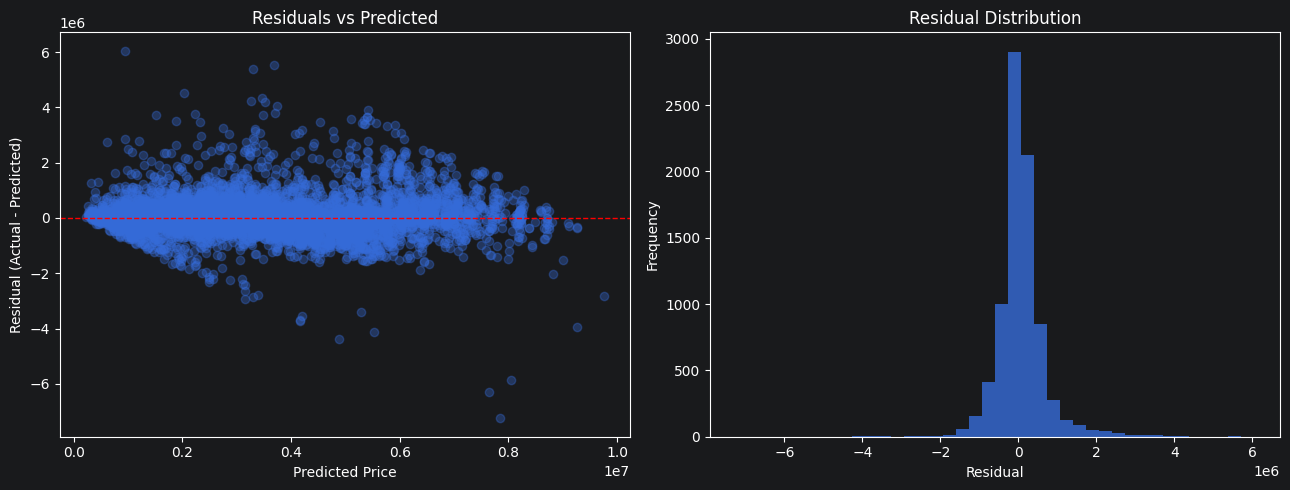

In [7]:
predictions = np.asarray(selected_model.predict(X_test_adj), dtype=float)
y_true = np.asarray(y_test, dtype=float)
residuals = y_true - predictions

mae = float(mean_absolute_error(y_true, predictions))
rmse = float(np.sqrt(mean_squared_error(y_true, predictions)))
r2 = float(r2_score(y_true, predictions))

print("-" * 60)
print("CAR PRICE REGRESSION REPORT")
print("-" * 60)
print(f"Rows used for training after cleaning: {len(car):,}")
print(f"Selected model variant: {selected_model_name}")
print("\nCross-validation (5-fold):")
print(f"  MAE : Rs. {scores_df.loc[selected_model_name, 'cv_mae']:,.2f}")
print(f"  RMSE: Rs. {scores_df.loc[selected_model_name, 'cv_rmse']:,.2f}")
print(f"  R2  : {scores_df.loc[selected_model_name, 'cv_r2']:.4f}")
print("\nHoldout test set:")
print(f"  MAE : Rs. {mae:,.2f}")
print(f"  RMSE: Rs. {rmse:,.2f}")
print(f"  R2  : {r2:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(predictions, residuals, alpha=0.35)
axes[0].axhline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_title("Residuals vs Predicted")
axes[0].set_xlabel("Predicted Price")
axes[0].set_ylabel("Residual (Actual - Predicted)")

axes[1].hist(residuals, bins=40, alpha=0.8)
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


### 8. Save artifacts and show sample predictions

In [8]:
ARTIFACTS_DIR.mkdir(exist_ok=True)

comparison = pd.DataFrame(
    {
        "actual_price": y_true,
        "predicted_price": predictions,
        "residual": residuals,
        "absolute_error": np.abs(residuals),
    }
)

model_path = ARTIFACTS_DIR / "car_price_best_model.pkl"
metrics_path = ARTIFACTS_DIR / "metrics.json"
predictions_path = ARTIFACTS_DIR / "test_predictions.csv"

joblib.dump(selected_model, model_path)
comparison.to_csv(predictions_path, index=False)

payload = {
    "selected_model": selected_model_name,
    "cv_mae": float(scores_df.loc[selected_model_name, "cv_mae"]),
    "cv_rmse": float(scores_df.loc[selected_model_name, "cv_rmse"]),
    "cv_r2": float(scores_df.loc[selected_model_name, "cv_r2"]),
    "test_mae": mae,
    "test_rmse": rmse,
    "test_r2": r2,
    "age_mileage_correlation": age_mileage_corr,
    "multicollinearity_decision": multicollinearity_decision,
    "numeric_features_used": numeric_features,
    "categorical_features_used": categorical_features,
    "artifacts": {
        "model_path": str(model_path.resolve()),
        "predictions_path": str(predictions_path.resolve()),
    },
}
metrics_path.write_text(json.dumps(payload, indent=2), encoding="utf-8")

print(f"Saved model to: {model_path}")
print(f"Saved metrics to: {metrics_path}")
print(f"Saved predictions to: {predictions_path}")

comparison.head().round(0)


Saved model to: artifacts\car_price_best_model.pkl
Saved metrics to: artifacts\metrics.json
Saved predictions to: artifacts\test_predictions.csv


,actual_price,predicted_price,residual,absolute_error
0,2200000.0,2184319.0,15681.0,15681.0
1,2290000.0,2195162.0,94838.0,94838.0
2,5400000.0,5336580.0,63420.0,63420.0
3,2925000.0,2889671.0,35329.0,35329.0
4,2200000.0,2296554.0,-96554.0,96554.0
